In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.patches as patches
import math

In [2]:
df = pd.read_csv("data/TCL_wt1.tsv", sep = "\t", na_values= "#VALEUR!")
df = df.dropna()

df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183,-3.009460,0.036746,1.434787


In [24]:
df.shape

(1746, 7)

In [3]:
values = df[['Description', 'Gene Symbol']]
values.head()

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB
5,Flagellar hook-associated protein 3 OS=Escheri...,flgL


In [4]:
df.iloc[:,[0, 2, 3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
4,P05706,srlB,0.108497
5,P29744,flgL,0.124183
...,...,...,...
2011,P77330,borD,1.535948
2016,P02930,tolC,1.552288
2020,P0A917,ompX,1.579739
2021,P02931,ompF,1.754902


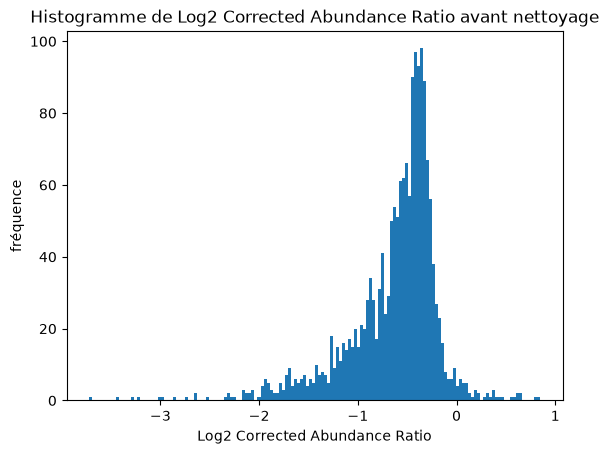

In [5]:
plt.hist(df["Log2 Corrected Abundance Ratio"], bins = (150))
plt.title("Histogramme de Log2 Corrected Abundance Ratio avant nettoyage")
plt.xlabel("Log2 Corrected Abundance Ratio")
plt.ylabel("fréquence")
plt.savefig("hist_log2_avant")

In [6]:
df_filt = df.loc[(df['Log2 Corrected Abundance Ratio'] > -2.5 ) ]

In [7]:
mu = df_filt['Log2 Corrected Abundance Ratio'].mean()
sigma = df_filt['Log2 Corrected Abundance Ratio'].std()

In [8]:
print(mu, sigma)

-0.6236474194622479 0.43193865548866134


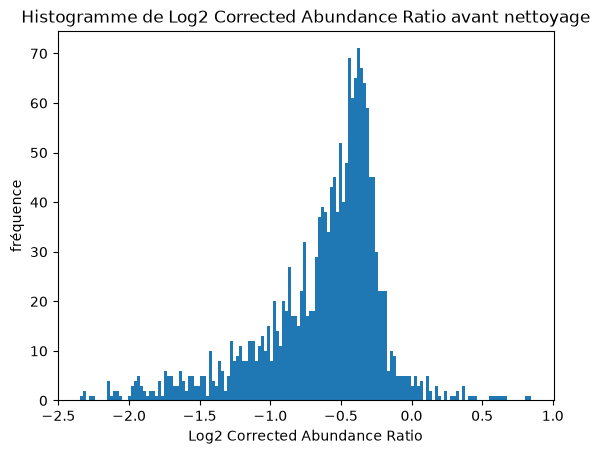

In [9]:
plt.hist(df_filt["Log2 Corrected Abundance Ratio"], bins = (150))
plt.title("Histogramme de Log2 Corrected Abundance Ratio avant nettoyage")
plt.xlabel("Log2 Corrected Abundance Ratio")
plt.ylabel("fréquence")
plt.savefig("hist_log2_après")

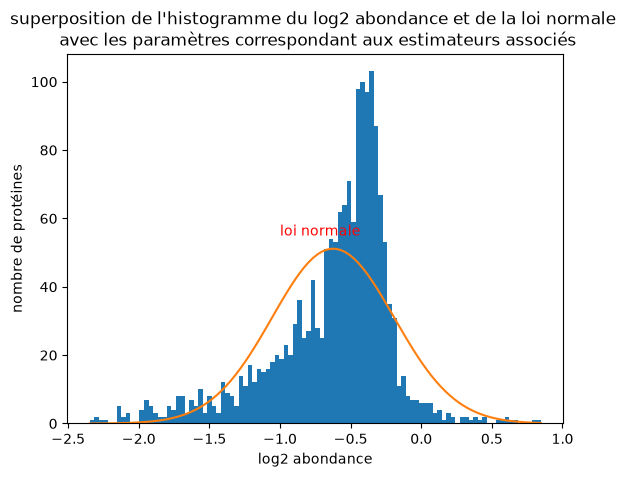

In [10]:
ig, ax = plt.subplots()
hist = ax.hist(df_filt["Log2 Corrected Abundance Ratio"], bins=100) # draw histogram
x = np.linspace(min(df_filt["Log2 Corrected Abundance Ratio"]), max(df_filt["Log2 Corrected Abundance Ratio"]), 100) # generate PDF domain points
dx = hist[1][1] - hist[1][0] # Get single value bar height
scale = len(df_filt["Log2 Corrected Abundance Ratio"])*dx # scale accordingly
ax.plot(x, norm.pdf(x, mu, sigma)*scale) # compute theoritical PDF and draw it
plt.xlabel("log2 abondance")
plt.ylabel("nombre de protéines")
plt.title("superposition de l'histogramme du log2 abondance et de la loi normale \n avec les paramètres correspondant aux estimateurs associés")
ax.text(-1, 55, "loi normale", color = "r")
plt.savefig("hist_loi_norm")

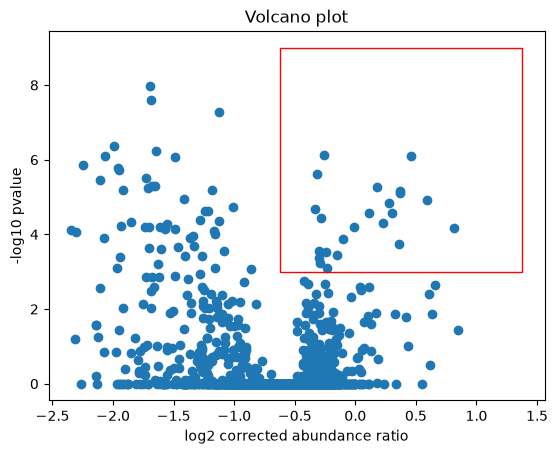

In [11]:
seuil_log10 = -math.log10(0.001)
ig, ax = plt.subplots()
ax.scatter(df_filt["Log2 Corrected Abundance Ratio"], df_filt["-LOG10 Adj.P-val"])
ax.add_patch(patches.Rectangle((mu,seuil_log10), 2, 6, fill = False, edgecolor = "red"))
ax.plot()
plt.xlabel("log2 corrected abundance ratio")
plt.ylabel("-log10 pvalue")
plt.title("Volcano plot")
plt.savefig("Volcano_plot")

In [12]:
prot_ab = df_filt.loc[(df_filt['Log2 Corrected Abundance Ratio'] > mu ) & (df_filt['-LOG10 Adj.P-val'] > seuil_log10 )]
prot_ab.shape

(23, 7)

In [13]:
acc = list(prot_ab["Accession"])

In [14]:
from xml.etree.ElementTree import parse, dump

def getAccessionGOTerms(xmlFile, accession):
    tree = parse(xmlFile)
    root = tree.getroot()
    ns = '{http://uniprot.org/uniprot}'
    
    match_go_terms = []
    proteins = root.findall(ns + 'entry')
    for entry in proteins:
        accessions = entry.findall(ns+"accession")
        current_accessions = [ acc.text for acc in accessions ]
        if not accession in current_accessions:
            continue
        goTerms = entry.findall('{http://uniprot.org/uniprot}dbReference[@type="GO"]')
        #goTerms = xmlEntry.findall(ns +'dbReference[@type="GO"]')
        for goT in goTerms:
            gID   = goT.attrib['id']
            gName = goT.find(ns +'property[@type="term"]').attrib['value']
            match_go_terms.append((gID, gName))
        break
    return match_go_terms

In [15]:
xml_file = "data/uniprot-proteome_UP000000625.xml"

dict_go = dict()
for prot in acc :
    gos = getAccessionGOTerms(xml_file, prot)
    for go_id, go_name in gos : 
        if go_id not in dict_go.keys() :
            dict_go[go_id] = dict()
            dict_go[go_id]["ID"] = go_id
            dict_go[go_id]["name"] = go_name
            dict_go[go_id]["carried_by"] = []
        dict_go[go_id]["carried_by"].append(prot)

In [31]:
# cell outer membrane car max prots après cytosol
go2test = dict_go["GO:0009279"]
n = len(prot_ab) # nb d'observations = prot surabondantes dans pathway GOi
N = len(df) # nb d'éléments observables (protéome d'E. coli, nb de protéines observées... ?)
k = len(go2test["carried_by"]) # nb succès (= nb expérimental de prot surabondantes dans pathway GOi)

import json
with open ('data/EColiK12_GOcounts.json') as fp : 
    pw_stats = json.load(fp)
K = pw_stats["go_terms"]["GO:0009279"]["count"] # nb de prot dans le pathway théorique

114